In [1]:
pwd

'/Users/f0053cz/Dartmouth College Dropbox/Rekha Sreekumar Varrier/postdoc_Dartmouth/psyanim_behav_paper/version2/scripts_data_for_beh_paper/code/2_M1_M2_group_level_plots'

In [35]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [36]:
s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

In [37]:
# root_file = '/Users/f0053cz/Documents/psyanim_v2/subtlety/subtlety_v2_data_Zishan/data/raw_data_'
root_file = '../../data/subtlety_data/Dec_withmimic/dec_ses1/all_'
batch_name = 'dec_ses1'

In [38]:
# df = pd.read_csv('../data/all_dec_ses1.csv',index_col=[0])
df = pd.read_csv(f'{root_file}{batch_name}.csv')#,index_col=[0])
df.head() 

,stim_file,condition,subtlety,slider,RT,accuracy,subID,trial_ind
0,4c50352d-2e1e-4e2e-ad43-613002422011,mimic,90,0.0,3.395,1,1,0
1,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,76.0,3.437,1,1,1
2,5dbc75c6-6973-4ae1-aaf0-d3b84feb4723,wander,180,0.0,4.565,0,1,2
3,65ae3786-93f4-4878-bcfe-7cee118774dc,mimic,0,3.0,4.251,1,1,3
4,91659665-5079-44c4-96c1-49da784170fa,chase,60,78.0,3.606,1,1,4


In [39]:
df.loc[np.isnan(df['slider']),:].groupby(['subID']).count().sort_values(by=['stim_file'])

,stim_file,condition,subtlety,slider,RT,accuracy,trial_ind
subID,,,,,,,
4,1,1,1,0,1,1,1
241,1,1,1,0,1,1,1
239,1,1,1,0,1,1,1
235,1,1,1,0,1,1,1
232,1,1,1,0,1,1,1
...,...,...,...,...,...,...,...
198,3,3,3,0,3,3,3
220,3,3,3,0,3,3,3
125,3,3,3,0,3,3,3


In [40]:
# jitter_strength = .1
subtlety_array = np.unique(df['subtlety'])
subtlety_array

array([  0,  30,  60,  90, 120, 150, 180])

In [41]:
nsubs = np.unique(df['subID']).shape[0]
nsubs

308

In [42]:
palette = {'chase':'tab:blue','invis. chase\n(control)':'tab:grey','wander':'tab:blue'}

In [43]:
np.unique(df['condition'])

array(['chase', 'mimic', 'wander'], dtype=object)

In [44]:
df['slider']

0         0.0
1        76.0
2         0.0
3         3.0
4        78.0
         ... 
25867    23.0
25868    87.0
25869    98.0
25870     0.0
25871     0.0
Name: slider, Length: 25872, dtype: float64

In [45]:
df['slider'] /= 100
df['slider']

0        0.00
1        0.76
2        0.00
3        0.03
4        0.78
         ... 
25867    0.23
25868    0.87
25869    0.98
25870    0.00
25871    0.00
Name: slider, Length: 25872, dtype: float64

In [46]:
df.insert(3,'directness',0)
df['directness'] = [np.round((180-i)/180,2) for i in df['subtlety']]
df.head()

,stim_file,condition,subtlety,directness,slider,RT,accuracy,subID,trial_ind
0,4c50352d-2e1e-4e2e-ad43-613002422011,mimic,90,0.50,0.00,3.395,1,1,0
1,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,0.83,0.76,3.437,1,1,1
2,5dbc75c6-6973-4ae1-aaf0-d3b84feb4723,wander,180,0.00,0.00,4.565,0,1,2
3,65ae3786-93f4-4878-bcfe-7cee118774dc,mimic,0,1.00,0.03,4.251,1,1,3
4,91659665-5079-44c4-96c1-49da784170fa,chase,60,0.67,0.78,3.606,1,1,4


In [47]:
df_chase = df.loc[df['condition']!='mimic',:]
df_chase['condition'] = 'chase'
df_mimic = df.loc[df['condition']!='chase',:]
df_mimic['condition'] = 'invis. chase\n(control)'

/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_92031/2700387683.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_chase['condition'] = 'chase'
/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_92031/2700387683.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mimic['condition'] = 'invis. chase\n(control)'


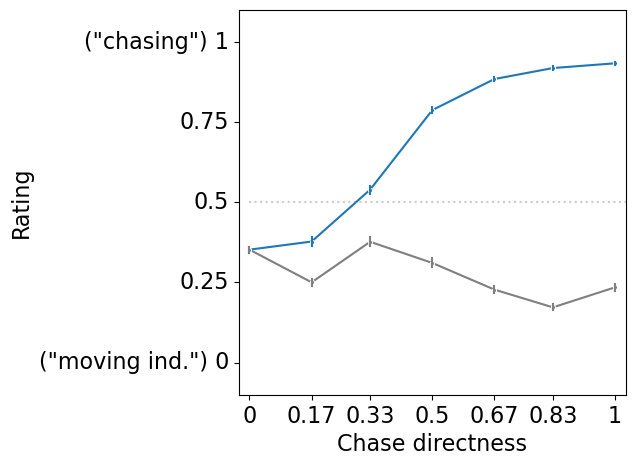

In [48]:
plt.figure(figsize=(5,5))
sns.lineplot(data = df_chase, x = 'directness', y = 'slider', hue = 'condition', marker = '.', palette=palette, legend = False, err_style='bars')
sns.lineplot(data = df_mimic, x = 'directness', y = 'slider', hue = 'condition', marker = '.', palette=palette, legend = False, err_style='bars')
plt.hlines(.50,0,1.1,ls=':',color = 'grey', alpha = .4)
plt.ylim(-.1,1.10)
plt.ylabel('Rating')
plt.xlabel('Chase directness')
plt.yticks(np.arange(0,1.01,.25),['("moving ind.") 0',"0.25","0.5","0.75",'("chasing") 1'],fontsize=16,va='center',ha='right')
plt.xticks(np.unique(df_chase['directness']), [str(np.round(i)).split('.')[0] if i in [0,1] else str(np.round(i,2)) for i in np.unique(df_chase['directness'])],fontsize=16, ha='center')
plt.xlim(-.03,1.03)
# Adding aligned text
ax = plt.gca()
labels = ax.get_yticklabels()

plt.savefig(f'../../results/subtlety/ratings_group_subtlety_{batch_name}_withmimic.png', dpi=300, bbox_inches='tight')

In [49]:
dist_flname= '../../data/subtlety_data/all_dist/save_all_dist.csv'
df_dist = pd.read_csv(dist_flname, index_col=[0])
df_dist.head()

,stim_file,condition,subtlety,all_dist,avg_dist,ntimepts
0,06f1dd04-cfbc-433c-9833-32cdb01c0683,chase,90.0,"[300.0, 299.3649514, 298.53592181, 297.4219242...",251.926324,336
1,07cdb9d7-6577-428d-9498-8a7243527554,chase,0.0,"[300.0, 299.73869272, 299.36885405, 298.763735...",127.312777,336
2,0a730462-ba50-4dbe-97c6-911f61a40346,chase,30.0,"[300.0, 297.89706415, 296.26654927, 294.076685...",172.501559,336
3,0b80e3d6-cded-42b9-b7ff-67c9cdbcb3c5,chase,30.0,"[300.0, 299.08444961, 297.9048105, 296.3411155...",154.886665,335
4,0ea51ff3-f8ac-4d29-a981-0a167d74909c,chase,30.0,"[300.0, 298.33708227, 296.86725385, 294.990731...",121.558008,337


In [50]:
df_dist = df_dist[['stim_file','all_dist','avg_dist','ntimepts']]
df_dist.head()

,stim_file,all_dist,avg_dist,ntimepts
0,06f1dd04-cfbc-433c-9833-32cdb01c0683,"[300.0, 299.3649514, 298.53592181, 297.4219242...",251.926324,336
1,07cdb9d7-6577-428d-9498-8a7243527554,"[300.0, 299.73869272, 299.36885405, 298.763735...",127.312777,336
2,0a730462-ba50-4dbe-97c6-911f61a40346,"[300.0, 297.89706415, 296.26654927, 294.076685...",172.501559,336
3,0b80e3d6-cded-42b9-b7ff-67c9cdbcb3c5,"[300.0, 299.08444961, 297.9048105, 296.3411155...",154.886665,335
4,0ea51ff3-f8ac-4d29-a981-0a167d74909c,"[300.0, 298.33708227, 296.86725385, 294.990731...",121.558008,337


In [51]:
df.shape, df_dist.shape

((25872, 9), (168, 4))

In [52]:
df_merged = df.merge(df_dist,how = 'inner', left_on = 'stim_file', right_on = 'stim_file')
df_merged.head()

,stim_file,condition,subtlety,directness,slider,RT,accuracy,subID,trial_ind,all_dist,avg_dist,ntimepts
0,4c50352d-2e1e-4e2e-ad43-613002422011,mimic,90,0.50,0.00,3.395,1,1,0,"[300.0, 298.9567539881035, 297.8423169606285, ...",202.821853,6536
1,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,0.83,0.76,3.437,1,1,1,"[300.0, 299.68131545, 299.42876064, 299.165219...",200.046966,335
2,5dbc75c6-6973-4ae1-aaf0-d3b84feb4723,wander,180,0.00,0.00,4.565,0,1,2,"[300.0, 300.52142607319536, 300.90930469097003...",342.902492,6600
3,65ae3786-93f4-4878-bcfe-7cee118774dc,mimic,0,1.00,0.03,4.251,1,1,3,"[300.0, 298.5480378470445, 297.4683306361171, ...",231.509617,6531
4,91659665-5079-44c4-96c1-49da784170fa,chase,60,0.67,0.78,3.606,1,1,4,"[300.0, 300.02555592, 300.05470601, 300.066995...",192.008513,335


In [53]:
len(np.unique(df_merged['stim_file']))

168

In [54]:
 # world size: 800 x 600.
max_dist = np.sqrt(800*800 + 600*600)
max_dist

np.float64(1000.0)

In [56]:
df_merged['avg_dist']

0        202.821853
1        200.046966
2        342.902492
3        231.509617
4        192.008513
            ...    
25867    201.741875
25868    187.675207
25869    200.046966
25870    220.715400
25871    276.201041
Name: avg_dist, Length: 25872, dtype: float64

In [57]:
if df_merged['slider'].max() > 1:
    df_merged['slider'] /= 100 
df_merged['avg_dist'] /= max_dist
df_merged['trial_ind'] /= 83
df_merged

,stim_file,condition,subtlety,directness,slider,RT,accuracy,subID,trial_ind,all_dist,avg_dist,ntimepts
0,4c50352d-2e1e-4e2e-ad43-613002422011,mimic,90,0.50,0.00,3.395,1,1,0.000000,"[300.0, 298.9567539881035, 297.8423169606285, ...",0.202822,6536
1,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,0.83,0.76,3.437,1,1,0.012048,"[300.0, 299.68131545, 299.42876064, 299.165219...",0.200047,335
2,5dbc75c6-6973-4ae1-aaf0-d3b84feb4723,wander,180,0.00,0.00,4.565,0,1,0.024096,"[300.0, 300.52142607319536, 300.90930469097003...",0.342902,6600
3,65ae3786-93f4-4878-bcfe-7cee118774dc,mimic,0,1.00,0.03,4.251,1,1,0.036145,"[300.0, 298.5480378470445, 297.4683306361171, ...",0.231510,6531
4,91659665-5079-44c4-96c1-49da784170fa,chase,60,0.67,0.78,3.606,1,1,0.048193,"[300.0, 300.02555592, 300.05470601, 300.066995...",0.192009,335
...,...,...,...,...,...,...,...,...,...,...,...,...
25867,b04bf045-4291-437c-b53e-6d779af76038,mimic,90,0.50,0.23,2.851,1,348,0.951807,"[300.0, 299.915748775526, 299.82400638345973, ...",0.201742,6577
25868,8d9b8961-4fb1-4413-b875-966e01b9963a,chase,60,0.67,0.87,3.819,1,348,0.963855,"[300.0, 299.43795861, 298.99394233, 298.503065...",0.187675,337
25869,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,0.83,0.98,2.647,1,348,0.975904,"[300.0, 299.68131545, 299.42876064, 299.165219...",0.200047,335
25870,ed0ef852-3813-4796-8ef5-3a8bbef06e1b,mimic,30,0.83,0.00,3.317,0,348,0.987952,"[300.0, 298.47930730348446, 297.1341822988256,...",0.220715,6585


In [58]:
df_merged[['slider','subtlety', 'directness', 'avg_dist','trial_ind']].describe()

,slider,subtlety,directness,avg_dist,trial_ind
count,25760.000000,25872.00000,25872.000000,25872.000000,25872.000000
mean,0.479974,90.00000,0.500000,0.246468,0.500000
std,0.359880,60.00116,0.332873,0.088744,0.292138
min,0.000000,0.00000,0.000000,0.121558,0.000000
25%,0.120000,30.00000,0.170000,0.178992,0.250000
50%,0.470000,90.00000,0.500000,0.240476,0.500000
75%,0.830000,150.00000,0.830000,0.294481,0.750000
max,1.000000,180.00000,1.000000,0.580780,1.000000


In [59]:
df_merged['avg_dist'].min()

np.float64(0.121558007545988)

In [60]:
df_merged['avg_dist'] -=  df_merged['avg_dist'].min()
df_merged['avg_dist'] /= df_merged['avg_dist'].max()
df_merged[ 'avg_dist'].describe()

count    25872.000000
mean         0.272003
std          0.193248
min          0.000000
25%          0.125069
50%          0.258956
75%          0.376557
max          1.000000
Name: avg_dist, dtype: float64

## LME

In [61]:
from pymer4.models import Lmer

In [62]:
df_merged_nowander = df_merged.loc[df_merged['condition']!='wander',:]
df_merged_nowander.shape

(22176, 12)

In [63]:
missed_trials = df_merged_nowander.loc[np.isnan(df_merged_nowander['slider']),:].sort_values(by=['subID'])
missed_trials.head()

,stim_file,condition,subtlety,directness,slider,RT,accuracy,subID,trial_ind,all_dist,avg_dist,ntimepts
252,57dbdc86-9c49-4214-a908-c4a254e90229,chase,30,0.83,NaN,10.012,0,4,0.000000,"[300.0, 299.94054609, 299.88852903, 299.748055...",0.025353,336
383,7e4763cb-3bf2-48e1-a717-5314c5f41fa6,mimic,90,0.50,NaN,10.015,0,5,0.566265,"[300.0, 298.6259672422776, 297.4246356068592, ...",0.400660,6559
781,cca827ad-af9d-4cfd-ae71-7e028e3f8520,chase,60,0.67,NaN,10.008,0,10,0.301205,"[300.0, 299.65655624, 299.23947374, 298.815132...",0.294430,335
783,1133544c-e02a-40fa-8f0e-321e09bfaf18,mimic,0,1.00,NaN,10.013,0,10,0.325301,"[300.0, 299.7405711615924, 299.5314145883871, ...",0.408979,6495
879,0a730462-ba50-4dbe-97c6-911f61a40346,chase,30,0.83,NaN,10.008,0,11,0.469880,"[300.0, 297.89706415, 296.26654927, 294.076685...",0.110935,336


In [64]:
missed_trials.groupby(['subID']).count().sort_values(by=['stim_file'])

,stim_file,condition,subtlety,directness,slider,RT,accuracy,trial_ind,all_dist,avg_dist,ntimepts
subID,,,,,,,,,,,
4,1,1,1,1,0,1,1,1,1,1,1
186,1,1,1,1,0,1,1,1,1,1,1
188,1,1,1,1,0,1,1,1,1,1,1
336,1,1,1,1,0,1,1,1,1,1,1
191,1,1,1,1,0,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...
314,2,2,2,2,0,2,2,2,2,2,2
102,3,3,3,3,0,3,3,3,3,3,3
114,3,3,3,3,0,3,3,3,3,3,3


In [65]:
missed_trials.groupby(['subID']).count().iloc[:,0].values

array([1, 1, 2, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 2, 1, 1, 1, 1, 3, 1, 3, 2,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1,
       2, 3, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 2, 1, 1, 1, 1])

In [66]:
df_merged_nowander_nonan = df_merged_nowander.loc[~np.isnan(df_merged_nowander['slider']),:]

In [67]:
model = Lmer('slider ~ condition*directness + avg_dist + trial_ind + (1|subID) + (1|stim_file)', data=df_merged_nowander_nonan) # ff: anglesm rfx: subject ID
model.fit()

Linear mixed model fit by REML [’lmerMod’]
Formula: slider~condition*directness+avg_dist+trial_ind+(1|subID)+(1|stim_file)

Family: gaussian	 Inference: parametric

Number of observations: 22085	 Groups: {'subID': 308.0, 'stim_file': 144.0}

Log-likelihood: 4253.556 	 AIC: -8489.112

Random effects:

                  Name    Var    Std
subID      (Intercept)  0.006  0.076
stim_file  (Intercept)  0.008  0.090
Residual                0.038  0.194

No random effect correlations specified

Fixed effects:



/Users/f0053cz/miniconda3/envs/pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.512,0.453,0.572,0.030,146.250,16.975,0.000,***
conditionmimic,0.035,-0.033,0.104,0.035,138.970,1.008,0.315,
directness,0.526,0.446,0.606,0.041,138.915,12.854,0.000,***
avg_dist,-0.518,-0.615,-0.421,0.049,138.752,-10.503,0.000,***
trial_ind,0.007,-0.001,0.016,0.004,21648.925,1.669,0.095,.
conditionmimic:directness,-0.699,-0.806,-0.591,0.055,138.967,-12.735,0.000,***


In [68]:
df_merged_nomimic = df_merged.loc[df_merged['condition']!='mimic',:]
df_merged_nomimic_nonan = df_merged_nomimic.loc[~np.isnan(df_merged_nomimic['slider']),:]
df_merged_nomimic_nonan.head()

,stim_file,condition,subtlety,directness,slider,RT,accuracy,subID,trial_ind,all_dist,avg_dist,ntimepts
1,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,0.83,0.76,3.437,1,1,0.012048,"[300.0, 299.68131545, 299.42876064, 299.165219...",0.170917,335
2,5dbc75c6-6973-4ae1-aaf0-d3b84feb4723,wander,180,0.00,0.00,4.565,0,1,0.024096,"[300.0, 300.52142607319536, 300.90930469097003...",0.481999,6600
4,91659665-5079-44c4-96c1-49da784170fa,chase,60,0.67,0.78,3.606,1,1,0.048193,"[300.0, 300.02555592, 300.05470601, 300.066995...",0.153413,335
6,5d69d5c8-83dd-43c4-be85-f1c2ff45960d,chase,120,0.33,0.69,3.325,1,1,0.072289,"[300.0, 299.20015025, 298.17159048, 297.054313...",0.125261,340
7,42ffed3d-edac-4ca7-9b33-6f525cb7c364,chase,90,0.50,0.87,4.006,1,1,0.084337,"[300.0, 298.86291357, 297.89420067, 296.525538...",0.029343,336


In [69]:
df_merged_nochase = df_merged.loc[df_merged['condition']!='chase',:]
df_merged_nochase_nonan = df_merged_nochase.loc[~np.isnan(df_merged_nochase['slider']),:]
df_merged_nochase_nonan.head()

,stim_file,condition,subtlety,directness,slider,RT,accuracy,subID,trial_ind,all_dist,avg_dist,ntimepts
0,4c50352d-2e1e-4e2e-ad43-613002422011,mimic,90,0.50,0.00,3.395,1,1,0.000000,"[300.0, 298.9567539881035, 297.8423169606285, ...",0.176960,6536
2,5dbc75c6-6973-4ae1-aaf0-d3b84feb4723,wander,180,0.00,0.00,4.565,0,1,0.024096,"[300.0, 300.52142607319536, 300.90930469097003...",0.481999,6600
3,65ae3786-93f4-4878-bcfe-7cee118774dc,mimic,0,1.00,0.03,4.251,1,1,0.036145,"[300.0, 298.5480378470445, 297.4683306361171, ...",0.239430,6531
5,e9db5801-6830-4609-97a0-46296598a5b7,mimic,150,0.17,0.09,2.884,1,1,0.060241,"[300.0, 300.75214581916146, 301.42263999428417...",0.440728,6491
11,866a8867-d05f-4a43-a450-97e5fd6015f8,mimic,90,0.50,0.04,3.083,1,1,0.132530,"[300.0, 299.2572112667264, 298.49832020430875,...",0.310493,6568


In [70]:
model = Lmer('slider ~ directness + avg_dist + trial_ind + (1|subID) + (1|stim_file)', data=df_merged_nomimic_nonan)
model.fit()

Linear mixed model fit by REML [’lmerMod’]
Formula: slider~directness+avg_dist+trial_ind+(1|subID)+(1|stim_file)

Family: gaussian	 Inference: parametric

Number of observations: 14724	 Groups: {'subID': 308.0, 'stim_file': 96.0}

Log-likelihood: 2939.663 	 AIC: -5865.326

Random effects:

                  Name    Var    Std
subID      (Intercept)  0.005  0.070
stim_file  (Intercept)  0.008  0.090
Residual                0.037  0.192

No random effect correlations specified

Fixed effects:



/Users/f0053cz/miniconda3/envs/pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.570,0.508,0.631,0.031,97.511,18.105,0.000,***
directness,0.471,0.401,0.542,0.036,92.982,13.053,0.000,***
avg_dist,-0.684,-0.844,-0.524,0.082,93.052,-8.369,0.000,***
trial_ind,0.011,0.000,0.021,0.005,14359.559,1.981,0.048,*


In [72]:
stats.pearsonr(df_merged_nomimic_nonan['directness'], df_merged_nomimic_nonan['avg_dist'])

PearsonRResult(statistic=np.float64(-0.6836670094950588), pvalue=np.float64(0.0))

In [73]:
stats.pearsonr(df_merged_nochase_nonan['directness'], df_merged_nochase_nonan['avg_dist'])

PearsonRResult(statistic=np.float64(-0.009928680377194006), pvalue=np.float64(0.2285253540710066))

In [71]:
model = Lmer('slider ~ directness + avg_dist + trial_ind + (1|subID) + (1|stim_file)', data=df_merged_nochase_nonan)
model.fit()

Linear mixed model fit by REML [’lmerMod’]
Formula: slider~directness+avg_dist+trial_ind+(1|subID)+(1|stim_file)

Family: gaussian	 Inference: parametric

Number of observations: 14711	 Groups: {'subID': 308.0, 'stim_file': 96.0}

Log-likelihood: 2202.447 	 AIC: -4390.895

Random effects:

                  Name    Var    Std
subID      (Intercept)  0.014  0.120
stim_file  (Intercept)  0.008  0.092
Residual                0.040  0.200

No random effect correlations specified

Fixed effects:



/Users/f0053cz/miniconda3/envs/pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.525,0.475,0.574,0.025,111.267,20.844,0.000,***
directness,-0.146,-0.199,-0.093,0.027,92.978,-5.394,0.000,***
avg_dist,-0.493,-0.594,-0.391,0.052,92.835,-9.517,0.000,***
trial_ind,-0.003,-0.014,0.009,0.006,14328.204,-0.443,0.658,


# accuracy

In [40]:
df_chase_mean = df_chase.groupby(['subID','subtlety']).mean().reset_index()
df_chase_mean['condition'] = 'chase'
df_chase_mean

,subID,subtlety,directness,slider,RT,accuracy,trial_ind,condition
0,1,0,1.00,0.951667,2.729333,1.000000,37.333333,chase
1,1,30,0.83,0.840000,3.109833,1.000000,35.333333,chase
2,1,60,0.67,0.803333,2.888667,1.000000,39.166667,chase
3,1,90,0.50,0.790000,2.835667,1.000000,49.333333,chase
4,1,120,0.33,0.678333,3.106500,0.833333,36.166667,chase
...,...,...,...,...,...,...,...,...
2151,348,60,0.67,0.923333,3.067000,1.000000,54.500000,chase
2152,348,90,0.50,0.635000,2.539833,1.000000,36.333333,chase
2153,348,120,0.33,0.293333,3.190000,0.833333,44.000000,chase
2154,348,150,0.17,0.230000,4.167500,0.833333,51.000000,chase


In [41]:
df_mimic_mean = df_mimic.groupby(['subID','subtlety']).mean().reset_index()
df_mimic_mean['condition'] = 'invis. chase\n(control)'
df_mimic_mean

,subID,subtlety,directness,slider,RT,accuracy,trial_ind,condition
0,1,0,1.00,0.278333,3.748500,1.000000,50.500000,invis. chase\n(control)
1,1,30,0.83,0.186667,3.496500,0.333333,36.666667,invis. chase\n(control)
2,1,60,0.67,0.223333,3.305167,0.500000,50.000000,invis. chase\n(control)
3,1,90,0.50,0.175000,3.014667,0.500000,18.666667,invis. chase\n(control)
4,1,120,0.33,0.486667,3.337667,0.333333,55.666667,invis. chase\n(control)
...,...,...,...,...,...,...,...,...
2151,348,60,0.67,0.100000,2.675167,0.500000,40.833333,invis. chase\n(control)
2152,348,90,0.50,0.166667,2.905167,0.666667,41.333333,invis. chase\n(control)
2153,348,120,0.33,0.020000,2.314667,0.333333,28.833333,invis. chase\n(control)
2154,348,150,0.17,0.086667,2.633000,0.666667,39.333333,invis. chase\n(control)


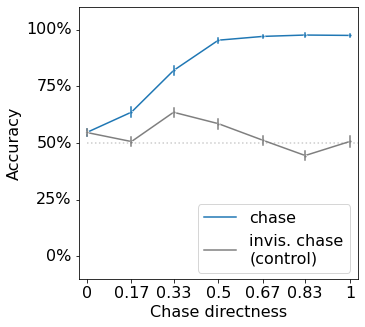

In [61]:
plt.figure(figsize=(5,5))
sns.lineplot(data = df_chase_mean, x = 'directness', y = 'accuracy', hue = 'condition', marker = '.', palette=palette, err_style='bars')
sns.lineplot(data = df_mimic_mean, x = 'directness', y = 'accuracy', hue = 'condition', marker = '.', palette=palette, err_style='bars')
plt.hlines(.5,0,1.1,ls=':',color = 'grey', alpha = .4)
plt.ylim(-.1,1.1)
plt.ylabel('Accuracy')
plt.xlabel('Chase directness')
plt.yticks(np.arange(0,1.1,.25),['0%',"25%","50%","75%",'100%'],fontsize=16, va='center',ha='right')

# Adding aligned text
ax = plt.gca()
labels = ax.get_yticklabels()

# Optionally, you can also align horizontally
labels = ax.get_xticklabels()
labels[-1].set_ha('center')  # Right-aligned

plt.xticks(np.unique(df_chase['directness']), [str(np.round(i)).split('.')[0] if i in [0,1] else str(np.round(i,2)) for i in np.unique(df_chase['directness'])],fontsize=16, ha='center')
plt.xlim(-.03,1.03)

plt.legend(bbox_to_anchor = [.9,.12],loc='lower right', bbox_transform=plt.gcf().transFigure)
plt.savefig(f'../../results/subtlety/accuracy_group_subtlety_{batch_name}_withmimic.png', dpi=300, bbox_inches='tight')

In [ ]:
from scipy import stats

In [ ]:
model = Lmer('accuracy ~ condition*directness + avg_dist + trial_ind + (1|subID) + (1|stim_file)', data=df_merged_nowander_nonan, family='binomial')
model.fit()

In [ ]:
model = Lmer('accuracy ~ directness + avg_dist + trial_ind + (1|subID) + (1|stim_file)', data=df_merged_nomimic_nonan, family='binomial')
model.fit()

In [ ]:
model = Lmer('accuracy ~ directness + avg_dist + trial_ind + (1|subID) + (1|stim_file)', data=df_merged_nochase_nonan, family='binomial')
model.fit()